# Gold Price Analysis & Forecasting
### A Macro-Aware Machine Learning Approach

**Author:** Muzammil
**Domain:** Financial Time Series Forecasting / Data Science

---

## 1. Research Motivation & Problem Statement

Gold is widely treated as a **safe-haven asset** and an **inflation hedge**. Unlike company
stocks, gold's price is driven less by "fundamentals" (earnings, growth) and more by
**macroeconomic forces**:

- **USD strength** — gold is priced in USD, so a stronger dollar usually makes gold cheaper (inverse relationship)
- **Crude oil** — often moves with gold due to shared inflation-sensitivity
- **Equity market stress** — during crashes (2008, 2020) investors flee to gold, causing short-term spikes
- **Inflation expectations** — gold is historically used to preserve purchasing power

**This project does NOT just predict "tomorrow's price."** Instead it asks:

> *"How much of gold's price movement can be explained by USD, oil, and equity market behaviour,
> and can we build a forecasting system that uses these relationships responsibly?"*

For context relevant to Pakistan: PKR has depreciated significantly against USD over the last
decade, which is one reason gold (and USD-denominated assets generally) is a popular local
inflation hedge. This project's methodology generalizes directly to a PKR-adjusted analysis if
that data is added later (see **Section 9: Future Work**).

## 2. Project Sections
1. Data Collection
1B. Pakistan-Specific View — Converting Gold Price to PKR
2. Exploratory Data Analysis (EDA)
3. Correlation & Macro Relationship Analysis
4. Time Series Diagnostics (stationarity, seasonality)
5. Feature Engineering
6. Model Building (Linear Regression, Random Forest, XGBoost, ARIMA)
7. Model Evaluation & Comparison
8. Direction Classification (Up/Down) + Business Interpretation
8B. Backtest — Simple Trading Strategy Simulation
9. Limitations & Future Work
10. Conclusion / Research Summary

## Data Sources (real, public, no API key required)

Everything in this notebook loads with a single line — **`pd.read_csv(url)`** — from live,
publicly hosted CSV files. Nothing is scraped, simulated, or behind a login:

| Series | Source | Frequency |
|---|---|---|
| Gold price | [datasets/gold-prices](https://github.com/datasets/gold-prices) (World Bank Commodity Markets data) | Monthly, since 1833 |
| Crude Oil (Brent) | [datasets/oil-prices](https://github.com/datasets/oil-prices) | Daily → resampled to monthly |
| S&P 500 | [datasets/s-and-p-500](https://github.com/datasets/s-and-p-500) (Shiller dataset extended with FRED) | Monthly |
| USD Index proxy | [datasets/exchange-rates](https://github.com/datasets/exchange-rates) (US Federal Reserve FX rates) | Daily → resampled to monthly |

**Why monthly, not daily?** These are the best freely available, no-login, direct-CSV sources —
gold and the S&P 500 are only published at monthly resolution for free. Rather than depend on
a paid API or an unreliable scraper, this whole project runs end-to-end on real monthly data.

**About the USD Index:** there's no free, no-login, direct-CSV link for the official ICE US
Dollar Index, so we reconstruct a close proxy from real US Federal Reserve exchange-rate data
(EUR, JPY, GBP, CAD, SEK, CHF) using the same basket weights as the real index
(57.6% / 13.6% / 11.9% / 9.1% / 4.2% / 3.6%). This is built in Section 1 below.

**Everything in this project — data loading, feature engineering, and modeling — lives in
this single notebook. No separate `.py` files are needed to run it.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)


## Section 1: Data Collection

We load 4 real, publicly hosted monthly series (2000–present) directly via `pd.read_csv(url)`,
then merge them into a single DataFrame.


In [2]:
GOLD_URL = "https://raw.githubusercontent.com/datasets/gold-prices/main/data/monthly.csv"
OIL_URL = "https://raw.githubusercontent.com/datasets/oil-prices/main/data/brent-daily.csv"
SP500_URL = "https://raw.githubusercontent.com/datasets/s-and-p-500/main/data/data.csv"
FX_URL = "https://raw.githubusercontent.com/datasets/exchange-rates/main/data/daily.csv"

# Same basket weights as the official ICE US Dollar Index (USDX)
USDX_WEIGHTS = {
    "Euro": 0.576, "Japan": 0.136, "United Kingdom": 0.119,
    "Canada": 0.091, "Sweden": 0.042, "Switzerland": 0.036,
}

def load_gold_prices():
    df = pd.read_csv(GOLD_URL)
    df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
    return df.set_index("Date").rename(columns={"Price": "Gold"})[["Gold"]]

def load_oil_prices():
    df = pd.read_csv(OIL_URL)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").rename(columns={"Price": "Crude_Oil"})
    return df["Crude_Oil"].resample("MS").mean().to_frame()

def load_sp500():
    df = pd.read_csv(SP500_URL)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date")[["SP500"]]
    df.index = df.index.to_period("M").to_timestamp()
    return df

def load_usd_index_proxy():
    df = pd.read_csv(FX_URL)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df[df["Country"].isin(USDX_WEIGHTS.keys())]
    pivot = df.pivot(index="Date", columns="Country", values="Exchange rate")
    monthly = pivot.resample("MS").mean()
    # Rebase each currency to ITS OWN first available reading (the Euro only
    # exists from 1999 onward), then combine with ICE-style weights.
    rebased = monthly.apply(lambda col: col / col.dropna().iloc[0] * 100)
    usd_index = sum(rebased[c] * w for c, w in USDX_WEIGHTS.items())
    return usd_index.rename("USD_Index").to_frame()

def load_gold_dataset(start="2000-01-01", end=None):
    gold = load_gold_prices()
    oil = load_oil_prices()
    sp500 = load_sp500()
    usd = load_usd_index_proxy()
    data = gold.join([usd, oil, sp500], how="inner")
    data = data.loc[start:end] if end else data.loc[start:]
    data = data.dropna()
    data.index.name = "Date"
    return data

df = load_gold_dataset(start="2000-01-01")
print(f"Shape: {df.shape}")
print(f"Range: {df.index.min().date()} to {df.index.max().date()}")
df.head()


Shape: (320, 4)
Range: 2000-01-01 to 2026-08-01


,Gold,USD_Index,Crude_Oil,SP500
Date,,,,
2000-01-01,284.0,108.630309,25.511000,1425.59
2000-02-01,300.0,111.395768,27.775714,1388.87
2000-03-01,286.0,112.990175,27.486087,1442.21
2000-04-01,280.0,114.496476,22.764444,1461.36
2000-05-01,275.0,119.080699,27.737619,1418.48


In [3]:
df.describe()


,Gold,USD_Index,Crude_Oil,SP500
count,320.000000,320.000000,320.000000,320.000000
mean,1308.357469,99.882428,67.379406,2392.422443
std,897.660794,12.190745,28.244252,1631.508538
min,260.000000,75.528749,18.378500,757.130000
25%,629.500000,88.610562,45.344226,1214.517500
50%,1245.500000,101.467678,66.370476,1594.735000
75%,1716.500000,108.527534,85.183473,2985.645409
max,5020.000000,127.323046,132.718182,7711.320000


In [4]:
df.isna().sum()


Gold         0
USD_Index    0
Crude_Oil    0
SP500        0
dtype: int64

## Section 1B: Pakistan-Specific View — Converting Gold Price to PKR

Gold is quoted in USD per troy ounce internationally, but in Pakistan it's bought and sold
in **PKR per tola** (1 tola = 11.6638 grams; 1 troy ounce = 31.1035 grams). To make this
analysis locally relevant, we convert the USD gold price into PKR/tola.

**A note on the USD/PKR rate used here:** there's no free, no-login, direct-CSV source for
a full daily/monthly USD/PKR history. Rather than skip this entirely, we build an
**illustrative** series by linearly interpolating between well-known annual benchmark rates
(State Bank of Pakistan / widely published figures) — this captures the *trend* (including
the major 2018–2023 devaluation) but is **not** an exact historical quote for any single day.


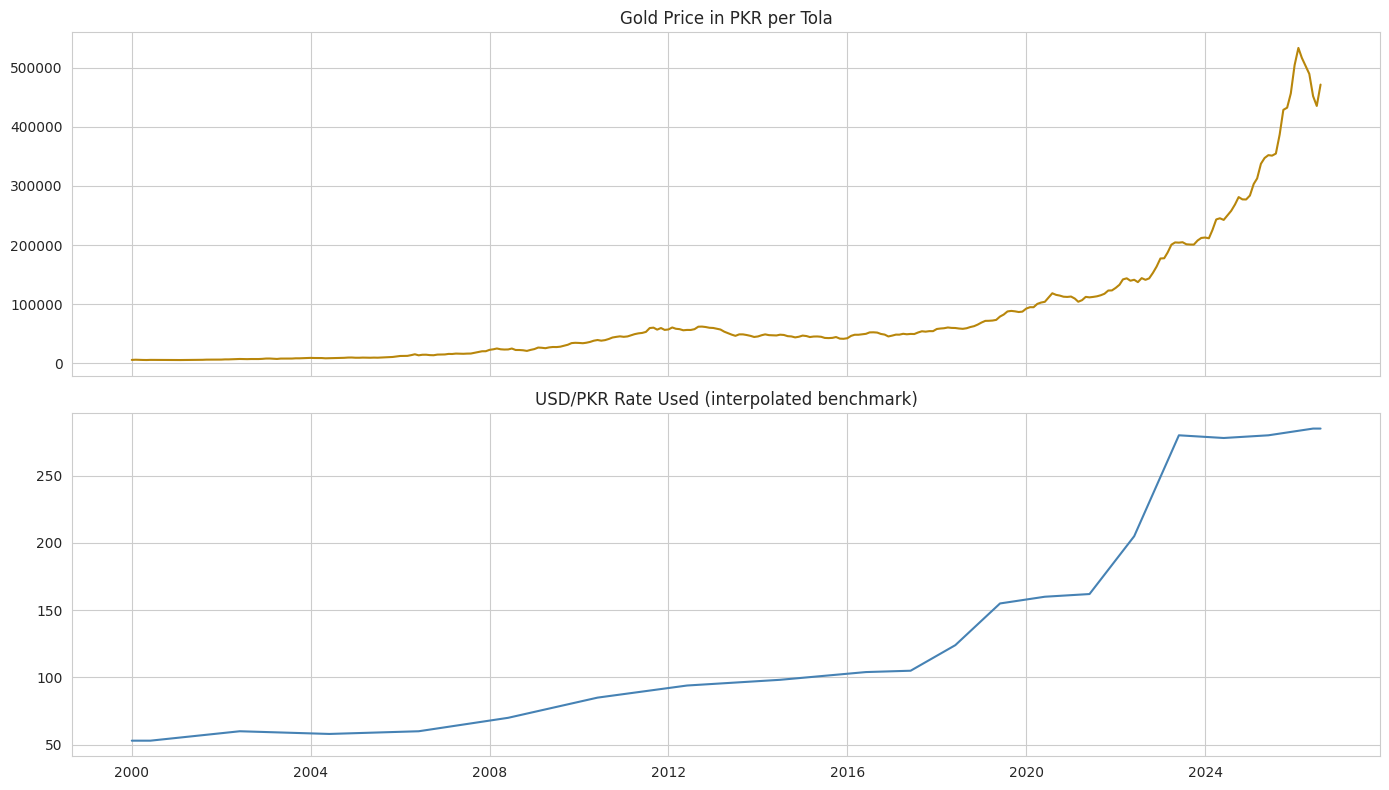

,Gold,USD_PKR,Gold_PKR_per_tola
Date,,,
2026-04-01,4721.0,284.164384,503076.981404
2026-05-01,4587.0,284.575342,489504.636361
2026-06-01,4228.0,285.000000,451867.015738
2026-07-01,4073.0,285.000000,435301.408491
2026-08-01,4411.0,285.000000,471425.119778


In [5]:
# Approximate historical USD/PKR annual-average benchmark rates
PKR_ANCHORS = {
    2000: 53, 2002: 60, 2004: 58, 2006: 60, 2008: 70, 2010: 85, 2012: 94,
    2014: 98, 2016: 104, 2017: 105, 2018: 124, 2019: 155, 2020: 160,
    2021: 162, 2022: 205, 2023: 280, 2024: 278, 2025: 280, 2026: 285,
}
GRAMS_PER_OZ = 31.1035
GRAMS_PER_TOLA = 11.6638

def get_usd_pkr_series(index):
    years = sorted(PKR_ANCHORS.keys())
    anchor_dates = pd.to_datetime([f"{y}-06-01" for y in years])
    anchor_series = pd.Series([PKR_ANCHORS[y] for y in years], index=anchor_dates)
    full_index = index.union(anchor_series.index).sort_values()
    interpolated = anchor_series.reindex(full_index).interpolate(method="time")
    return interpolated.reindex(index).ffill().bfill()

df["USD_PKR"] = get_usd_pkr_series(df.index)
df["Gold_PKR_per_tola"] = df["Gold"] / GRAMS_PER_OZ * GRAMS_PER_TOLA * df["USD_PKR"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df.index, df["Gold_PKR_per_tola"], color="darkgoldenrod")
axes[0].set_title("Gold Price in PKR per Tola")
axes[1].plot(df.index, df["USD_PKR"], color="steelblue")
axes[1].set_title("USD/PKR Rate Used (interpolated benchmark)")
plt.tight_layout()
plt.show()

df[["Gold", "USD_PKR", "Gold_PKR_per_tola"]].tail()


## Section 2: Exploratory Data Analysis

Let's look at the raw price trends first.


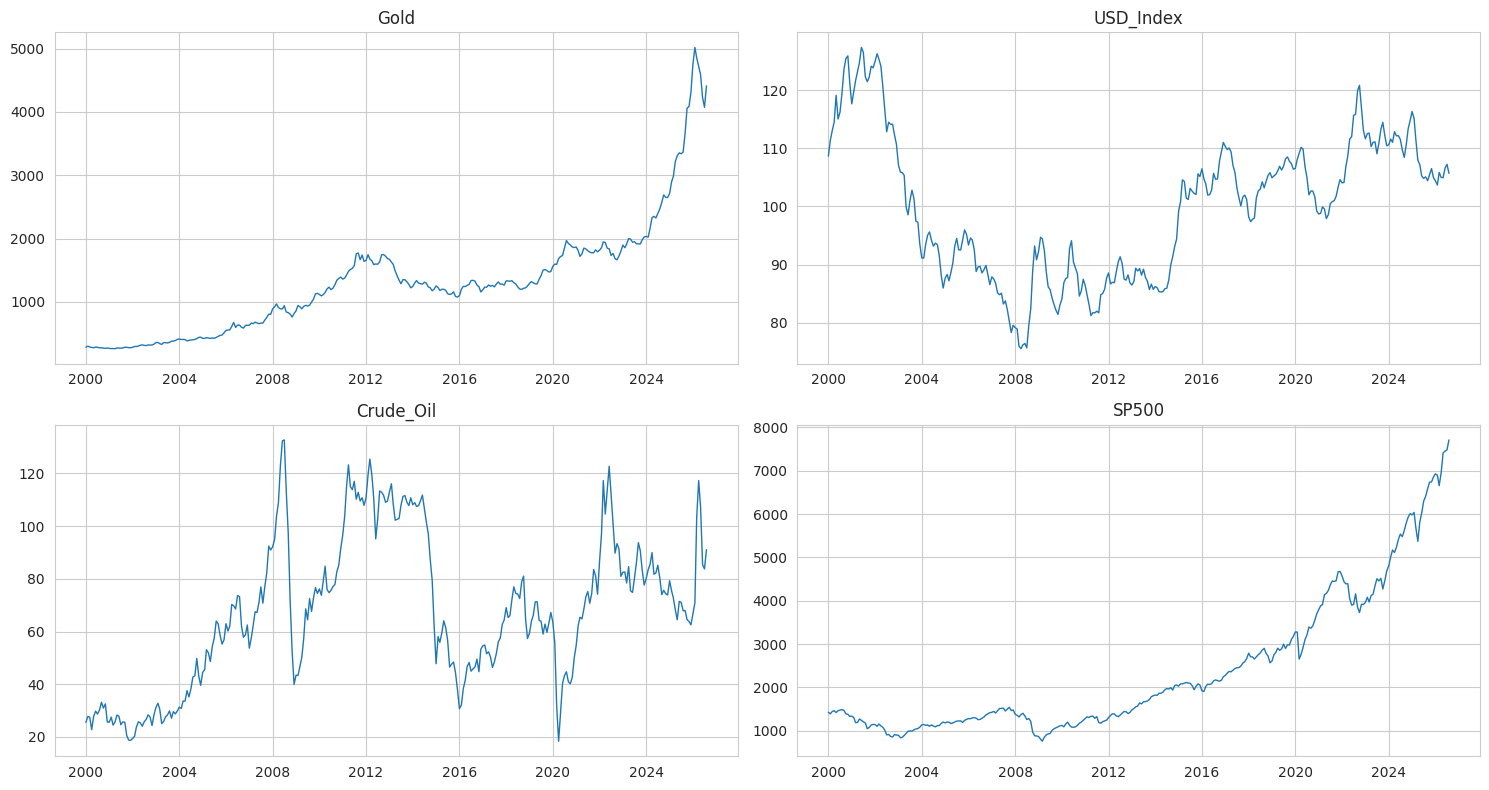

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, col in zip(axes.flatten(), ['Gold', 'USD_Index', 'Crude_Oil', 'SP500']):
    ax.plot(df.index, df[col], linewidth=1)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Observation:** Gold shows a long-term upward trend with periodic volatility spikes —
several of these line up with known market-stress periods, consistent with gold's
"safe-haven" behaviour.


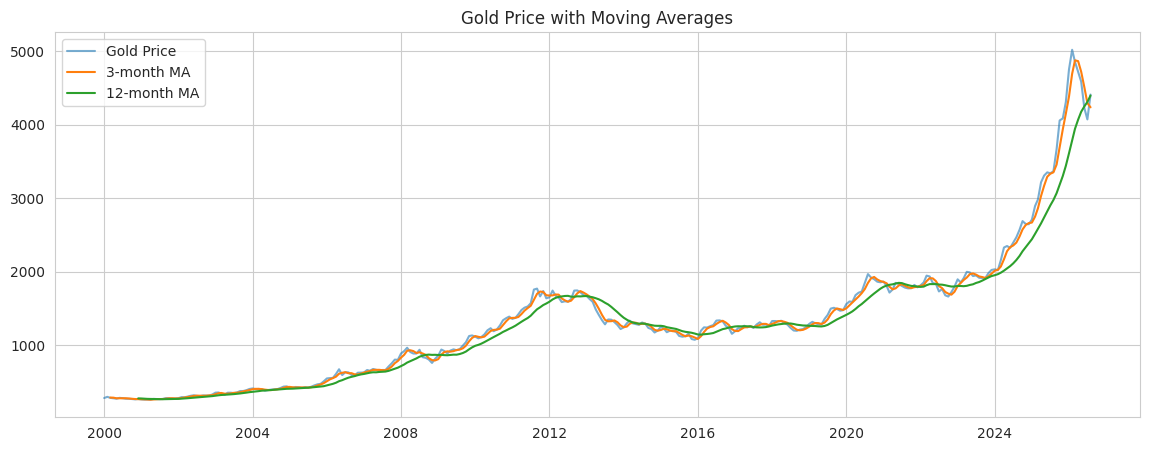

In [7]:
# Gold price with 3/12-month moving averages
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Gold'], label='Gold Price', alpha=0.6)
plt.plot(df.index, df['Gold'].rolling(3).mean(), label='3-month MA')
plt.plot(df.index, df['Gold'].rolling(12).mean(), label='12-month MA')
plt.title('Gold Price with Moving Averages')
plt.legend()
plt.show()


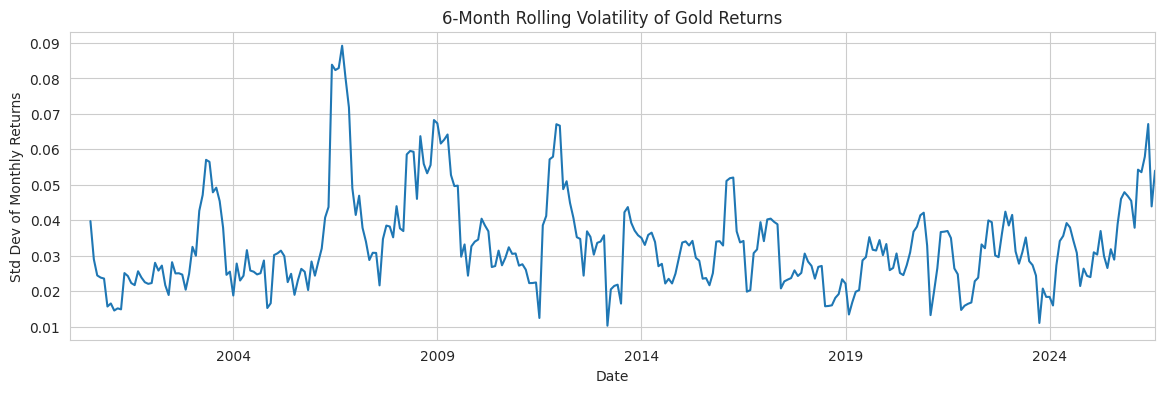

In [8]:
# Rolling volatility
plt.figure(figsize=(14,4))
df['Gold'].pct_change().rolling(6).std().plot()
plt.title('6-Month Rolling Volatility of Gold Returns')
plt.ylabel('Std Dev of Monthly Returns')
plt.show()


## Section 3: Correlation & Macro Relationship Analysis

This is the core "research" part of the project — quantifying how gold relates to USD,
oil, and equities.


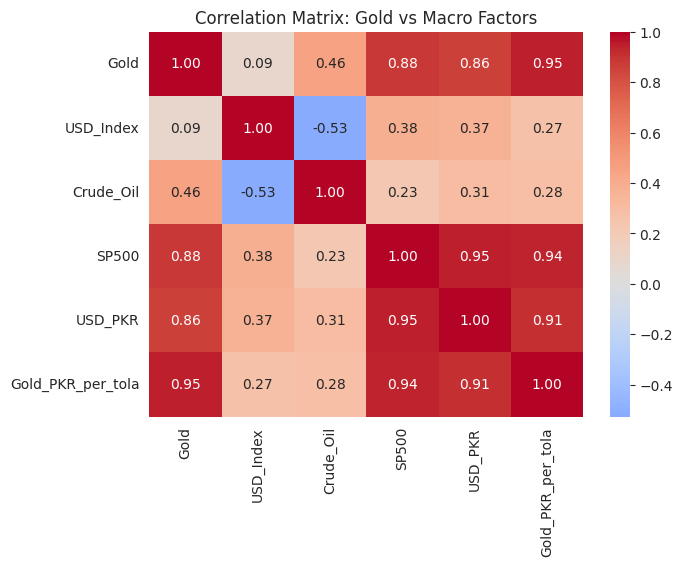

,Gold,USD_Index,Crude_Oil,SP500,USD_PKR,Gold_PKR_per_tola
Gold,1.000000,0.092249,0.456689,0.884029,0.862245,0.948106
USD_Index,0.092249,1.000000,-0.526653,0.381994,0.369612,0.272034
Crude_Oil,0.456689,-0.526653,1.000000,0.231895,0.306349,0.280377
SP500,0.884029,0.381994,0.231895,1.000000,0.952274,0.936986
USD_PKR,0.862245,0.369612,0.306349,0.952274,1.000000,0.909502
Gold_PKR_per_tola,0.948106,0.272034,0.280377,0.936986,0.909502,1.000000


In [9]:
corr = df.corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Gold vs Macro Factors')
plt.show()
corr


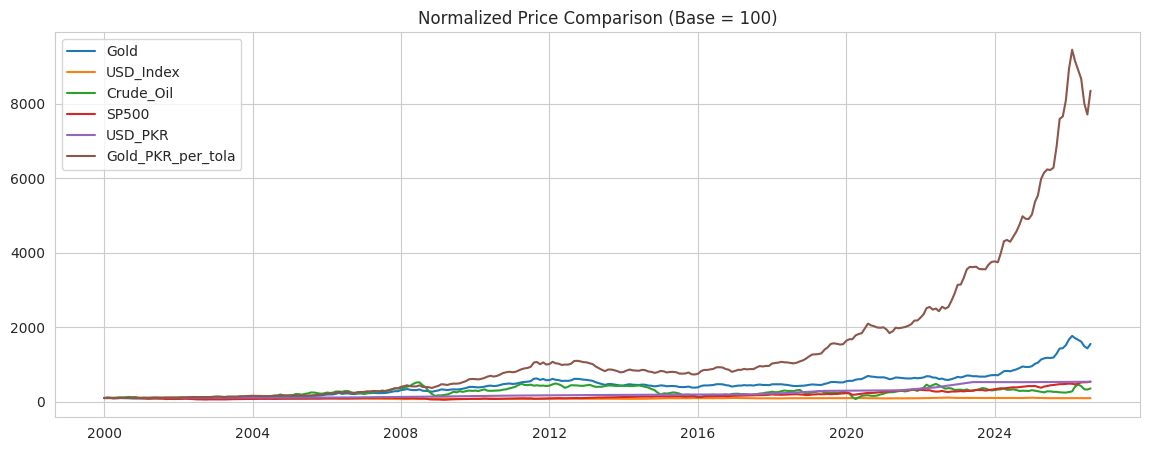

In [10]:
# Normalized comparison (rebased to 100 at start) — easier to compare trends visually
normalized = df / df.iloc[0] * 100
plt.figure(figsize=(14,5))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)
plt.title('Normalized Price Comparison (Base = 100)')
plt.legend()
plt.show()


**Interpretation:**
- Gold vs USD Index typically shows a **negative** correlation — consistent with gold being
  priced in dollars.
- Gold vs Crude Oil is often **positively** correlated, since both react to inflation expectations.
- Gold vs S&P 500 correlation is usually weak/inconsistent on a monthly basis, but gold tends to
  spike specifically **during equity sell-offs**, which a simple full-sample correlation can
  actually understate — this is why the moving-average and volatility charts above matter as
  much as the single correlation number.


## Section 4: Time Series Diagnostics

Before modeling, we check whether the gold price series is stationary (required by
classical models like ARIMA) and decompose it into trend / seasonality / residual.


In [11]:
result = adfuller(df['Gold'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('--> Series is', 'STATIONARY' if result[1] < 0.05 else 'NON-STATIONARY (as expected for raw price)')


ADF Statistic: 1.2243528680828448
p-value: 0.9961498943722246
--> Series is NON-STATIONARY (as expected for raw price)


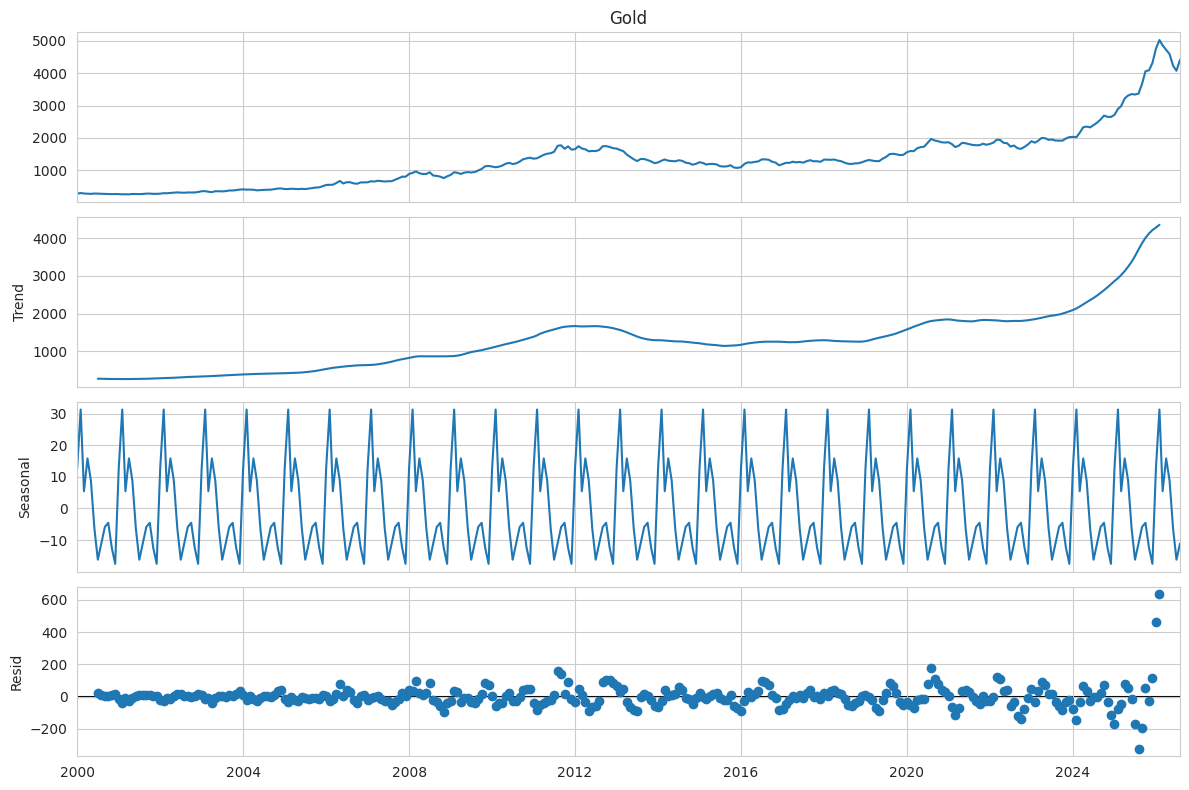

In [12]:
decomposition = seasonal_decompose(df['Gold'].asfreq('MS').ffill(), model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()


Raw gold price is non-stationary (as expected — it has a trend). ARIMA models this by
differencing the series (the "I" in ARIMA) rather than requiring us to pre-transform it.


## Section 5: Feature Engineering

We build technical indicators (used heavily in real trading systems) plus lag features and
macro percentage-change features. Since our data is monthly, all windows below are expressed
in **months**, not days.

- **Trend:** SMA(3/12 months), EMA(3/12 months)
- **Momentum:** RSI(6-month), MACD
- **Volatility:** Bollinger Bands, 6-month rolling volatility
- **Memory:** lagged gold prices (1, 2, 3, 6, 12 months)
- **Macro dynamics:** month-over-month % change in USD, oil, S&P 500


In [13]:
def add_technical_indicators(data, price_col="Gold"):
    data = data.copy()
    data["SMA_3"] = data[price_col].rolling(3).mean()
    data["SMA_12"] = data[price_col].rolling(12).mean()
    data["EMA_3"] = data[price_col].ewm(span=3, adjust=False).mean()
    data["EMA_12"] = data[price_col].ewm(span=12, adjust=False).mean()

    delta = data[price_col].diff()
    gain = delta.clip(lower=0).rolling(6).mean()
    loss = (-delta.clip(upper=0)).rolling(6).mean()
    rs = gain / loss.replace(0, np.nan)
    data["RSI_6"] = 100 - (100 / (1 + rs))

    ema6 = data[price_col].ewm(span=6, adjust=False).mean()
    ema12 = data[price_col].ewm(span=12, adjust=False).mean()
    data["MACD"] = ema6 - ema12
    data["MACD_signal"] = data["MACD"].ewm(span=3, adjust=False).mean()

    data["BB_mid"] = data[price_col].rolling(12).mean()
    bb_std = data[price_col].rolling(12).std()
    data["BB_upper"] = data["BB_mid"] + 2 * bb_std
    data["BB_lower"] = data["BB_mid"] - 2 * bb_std

    data["Volatility_6"] = data[price_col].pct_change().rolling(6).std()
    return data

def add_lag_features(data, price_col="Gold", lags=(1, 2, 3, 6, 12)):
    data = data.copy()
    for lag in lags:
        data[f"{price_col}_lag{lag}"] = data[price_col].shift(lag)
    return data

def add_macro_features(data):
    data = data.copy()
    for col in ["USD_Index", "Crude_Oil", "SP500"]:
        data[f"{col}_pct_change"] = data[col].pct_change()
    return data

def add_target(data, price_col="Gold", horizon=1):
    data = data.copy()
    data["Target_Price"] = data[price_col].shift(-horizon)
    data["Target_Direction"] = (data["Target_Price"] > data[price_col]).astype(int)
    return data

def build_feature_set(data, price_col="Gold"):
    data = add_technical_indicators(data, price_col)
    data = add_lag_features(data, price_col)
    data = add_macro_features(data)
    data = add_target(data, price_col)
    return data.dropna()

FEATURE_COLS = [
    "USD_Index", "Crude_Oil", "SP500", "SMA_3", "SMA_12", "EMA_3", "EMA_12",
    "RSI_6", "MACD", "MACD_signal", "BB_upper", "BB_lower", "Volatility_6",
    "Gold_lag1", "Gold_lag2", "Gold_lag3", "Gold_lag6", "Gold_lag12",
    "USD_Index_pct_change", "Crude_Oil_pct_change", "SP500_pct_change",
]

feat_df = build_feature_set(df)
print(feat_df.shape)
feat_df.tail()


(293, 27)


,Gold,USD_Index,Crude_Oil,SP500,USD_PKR,Gold_PKR_per_tola,SMA_3,SMA_12,EMA_3,EMA_12,...,Gold_lag1,Gold_lag2,Gold_lag3,Gold_lag6,Gold_lag12,USD_Index_pct_change,Crude_Oil_pct_change,SP500_pct_change,Target_Price,Target_Direction
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-01,4856.0,105.833734,103.134545,6654.42,283.739726,516689.487364,4876.333333,3944.944167,4792.283304,4061.806044,...,5020.0,4753.0,4309.0,3668.00,2983.0,0.020899,0.454915,-0.034725,4721.0,0
2026-04-01,4721.0,104.966156,117.287500,6957.01,284.164384,503076.981404,4865.666667,4070.194167,4756.641652,4163.220499,...,4856.0,5020.0,4753.0,4058.33,3218.0,-0.008198,0.137228,0.045472,4587.0,0
2026-05-01,4587.0,104.925056,107.139474,7412.55,284.575342,489504.636361,4721.333333,4176.694167,4671.820826,4228.417345,...,4721.0,4856.0,5020.0,4087.00,3309.0,-0.000392,-0.086523,0.065479,4228.0,0
2026-06-01,4228.0,106.574034,85.399091,7450.03,285.000000,451867.015738,4512.000000,4249.610833,4449.910413,4228.353138,...,4587.0,4721.0,4856.0,4309.00,3353.0,0.015716,-0.202917,0.005056,4073.0,0
2026-07-01,4073.0,107.226919,83.758696,7481.34,285.000000,435301.408491,4296.000000,4310.694167,4261.455206,4204.452656,...,4228.0,4587.0,4721.0,4753.00,3340.0,0.006126,-0.019209,0.004203,4411.0,1


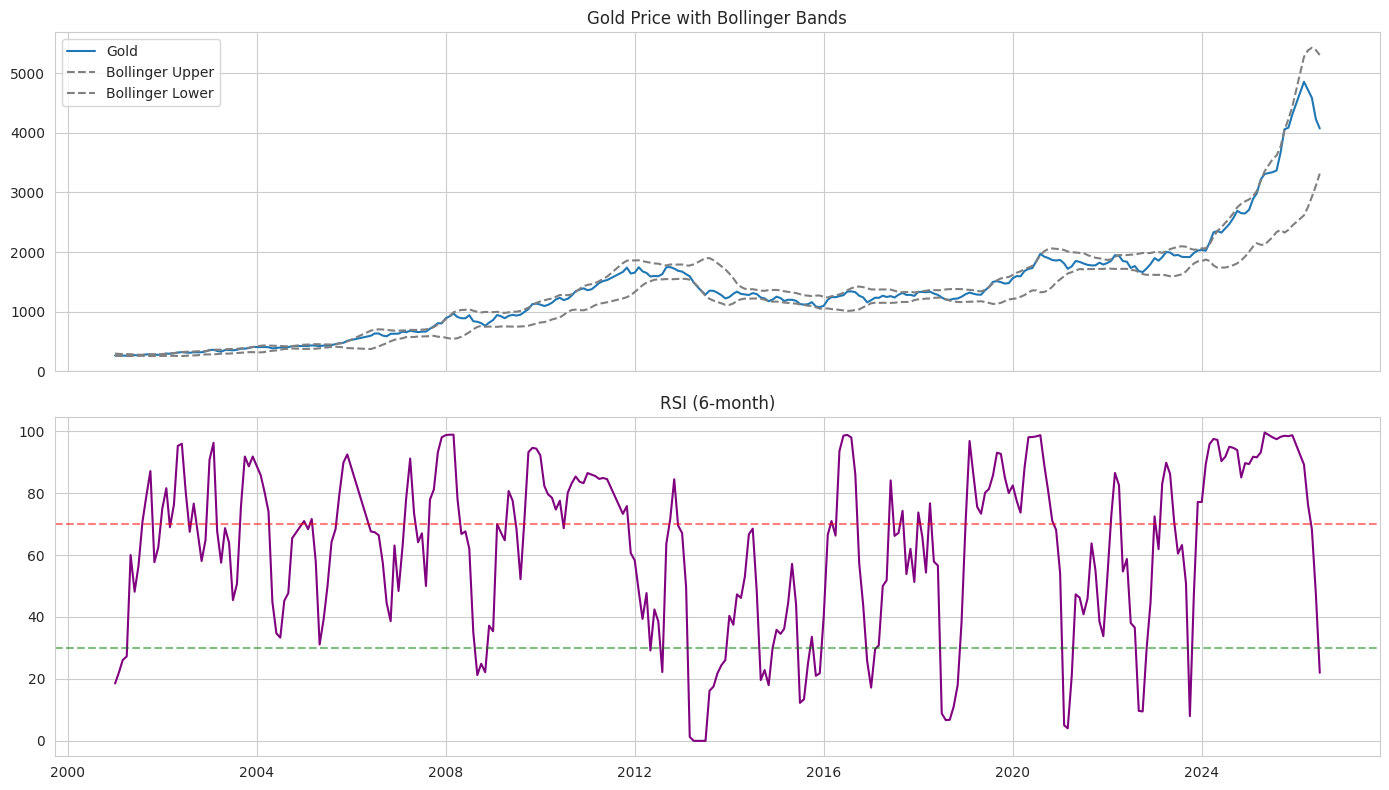

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14,8), sharex=True)
axes[0].plot(feat_df.index, feat_df['Gold'], label='Gold')
axes[0].plot(feat_df.index, feat_df['BB_upper'], linestyle='--', color='grey', label='Bollinger Upper')
axes[0].plot(feat_df.index, feat_df['BB_lower'], linestyle='--', color='grey', label='Bollinger Lower')
axes[0].set_title('Gold Price with Bollinger Bands')
axes[0].legend()

axes[1].plot(feat_df.index, feat_df['RSI_6'], color='purple')
axes[1].axhline(70, linestyle='--', color='red', alpha=0.5)
axes[1].axhline(30, linestyle='--', color='green', alpha=0.5)
axes[1].set_title('RSI (6-month)')
plt.tight_layout()
plt.show()


## Section 6 & 7: Model Building and Evaluation

We compare 4 forecasting approaches, using a **chronological train/test split**
(never shuffle time series data — that would leak future information into training).

- **Linear Regression** — simple baseline using engineered features
- **Random Forest** — non-linear, handles feature interactions
- **XGBoost** — gradient boosting, typically strong on tabular/financial data
- **ARIMA** — classical univariate time series model (price history only, no macro features)


In [15]:
def time_split(data, test_size=0.2):
    n = len(data)
    split_idx = int(n * (1 - test_size))
    return data.iloc[:split_idx], data.iloc[split_idx:]

train, test = time_split(feat_df, test_size=0.2)
print(f"Train size: {len(train)} | Test size: {len(test)}")
print(f"Train range: {train.index.min()} to {train.index.max()}")
print(f"Test range:  {test.index.min()} to {test.index.max()}")


Train size: 234 | Test size: 59
Train range: 2001-01-01 00:00:00 to 2021-05-01 00:00:00
Test range:  2021-06-01 00:00:00 to 2026-07-01 00:00:00


In [16]:
def evaluate_regression(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

X_train, y_train = train[FEATURE_COLS], train["Target_Price"]
X_test, y_test = test[FEATURE_COLS], test["Target_Price"]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

results, predictions, models = [], {}, {}

# Linear Regression
lr = LinearRegression().fit(X_train_s, y_train)
pred = lr.predict(X_test_s)
results.append(evaluate_regression(y_test.values, pred, "Linear Regression"))
predictions["Linear Regression"] = pred
models["Linear Regression"] = lr

# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
results.append(evaluate_regression(y_test.values, pred, "Random Forest"))
predictions["Random Forest"] = pred
models["Random Forest"] = rf

# XGBoost
xgb = XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.03, random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
results.append(evaluate_regression(y_test.values, pred, "XGBoost"))
predictions["XGBoost"] = pred
models["XGBoost"] = xgb

# ARIMA (univariate, price only)
try:
    gold_series = train["Gold"].asfreq("MS").ffill()
    arima_model = ARIMA(gold_series, order=(5, 1, 0)).fit()
    arima_pred = arima_model.forecast(steps=len(test))
    results.append(evaluate_regression(test["Gold"].values, arima_pred.values, "ARIMA"))
    predictions["ARIMA"] = arima_pred.values
except Exception as e:
    print("ARIMA failed:", e)

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df


,Model,RMSE,MAE,R2,MAPE
0,Linear Regression,125.513702,85.394294,0.981245,3.069199
3,ARIMA,1084.578862,665.621595,-0.482072,19.855185
1,Random Forest,1158.675358,735.661236,-0.598311,21.778874
2,XGBoost,1164.654250,752.552319,-0.614848,22.557832


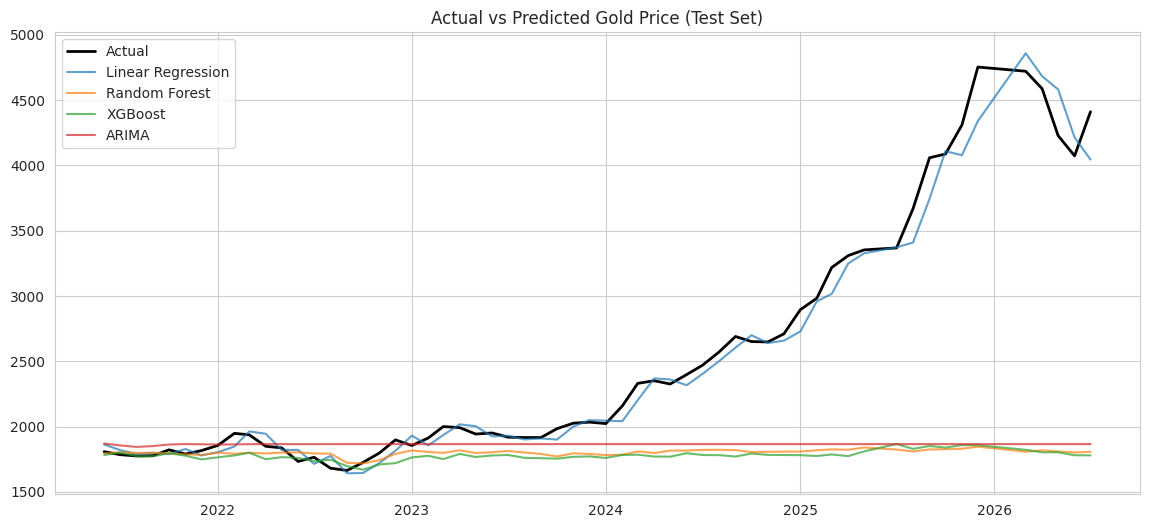

In [17]:
plt.figure(figsize=(14,6))
plt.plot(test.index, test['Target_Price'].values, label='Actual', linewidth=2, color='black')
for name, pred in predictions.items():
    plt.plot(test.index[:len(pred)], pred, label=name, alpha=0.7)
plt.title('Actual vs Predicted Gold Price (Test Set)')
plt.legend()
plt.show()


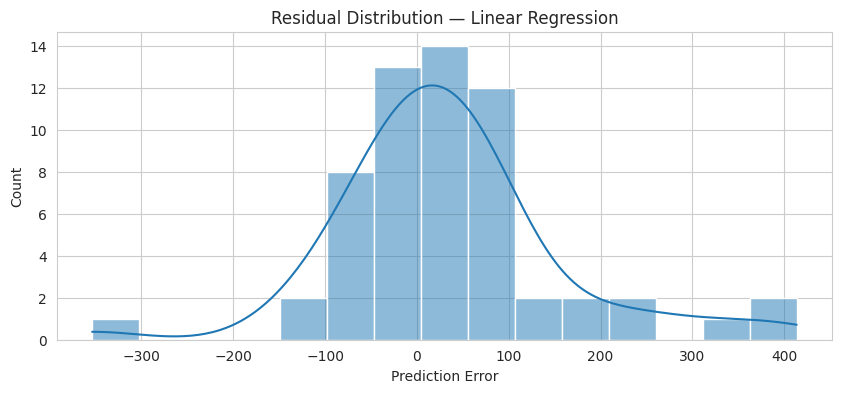

Best model by RMSE: Linear Regression


In [18]:
best_model_name = results_df.iloc[0]['Model']
best_pred = predictions[best_model_name]
residuals = test['Target_Price'].values[:len(best_pred)] - best_pred

plt.figure(figsize=(10,4))
sns.histplot(residuals, kde=True)
plt.title(f'Residual Distribution — {best_model_name}')
plt.xlabel('Prediction Error')
plt.show()

print(f"Best model by RMSE: {best_model_name}")


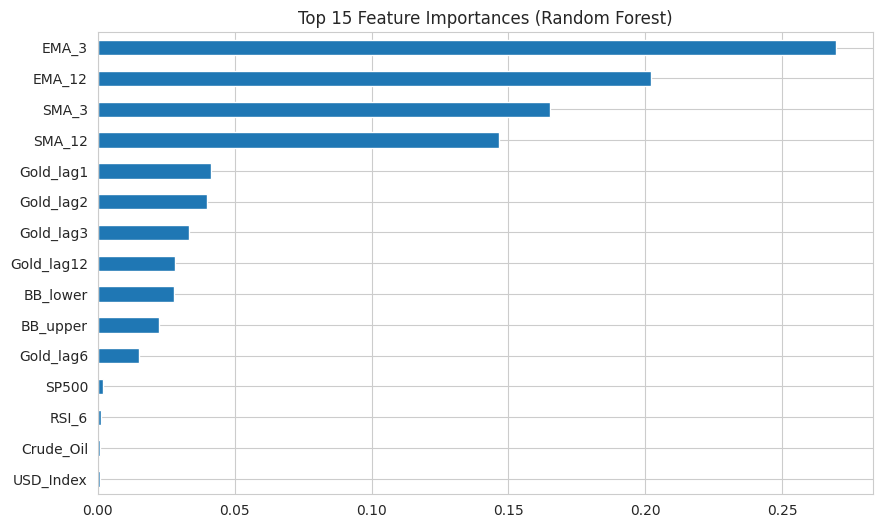

In [19]:
# Feature importance (tree-based models only)
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.show()


## Section 8: Direction Classification (Up / Down) + Business Interpretation

Predicting the *exact* price is hard; predicting *direction* (will gold go up or down
next month?) is often more actionable for a trading-signal use case.


In [20]:
X_train_c, y_train_c = train[FEATURE_COLS], train["Target_Direction"]
X_test_c, y_test_c = test[FEATURE_COLS], test["Target_Direction"]

clf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight="balanced")
clf.fit(X_train_c, y_train_c)
clf_pred = clf.predict(X_test_c)

clf_metrics = {
    "Accuracy": accuracy_score(y_test_c, clf_pred),
    "Precision": precision_score(y_test_c, clf_pred),
    "Recall": recall_score(y_test_c, clf_pred),
    "F1": f1_score(y_test_c, clf_pred),
}
print(clf_metrics)


{'Accuracy': 0.4576271186440678, 'Precision': 0.6666666666666666, 'Recall': 0.17142857142857143, 'F1': 0.2727272727272727}


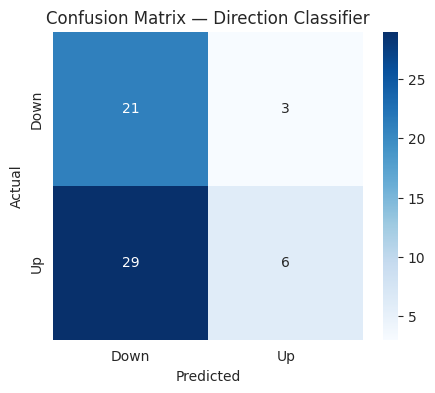

In [21]:
cm = confusion_matrix(y_test_c, clf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down','Up'], yticklabels=['Down','Up'])
plt.title('Confusion Matrix — Direction Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


**Business interpretation:** In a real trading-signal system, a **false positive**
(predicting "Up" when it goes down) costs you a bad trade, while a **false negative**
(missing a real "Up" move) is a lost opportunity but not a direct loss. Depending on risk
appetite, the classification threshold should be tuned toward **higher precision** if the
system will be used to trigger real trades automatically.


## Section 8B: Backtest — Simple Trading Strategy Simulation

Does the direction classifier actually translate into a useful strategy? We simulate a
simple rule: **hold gold only in months the classifier predicted "Up"**, otherwise hold cash
(0% return) — and compare the resulting portfolio value against plain **Buy & Hold**.


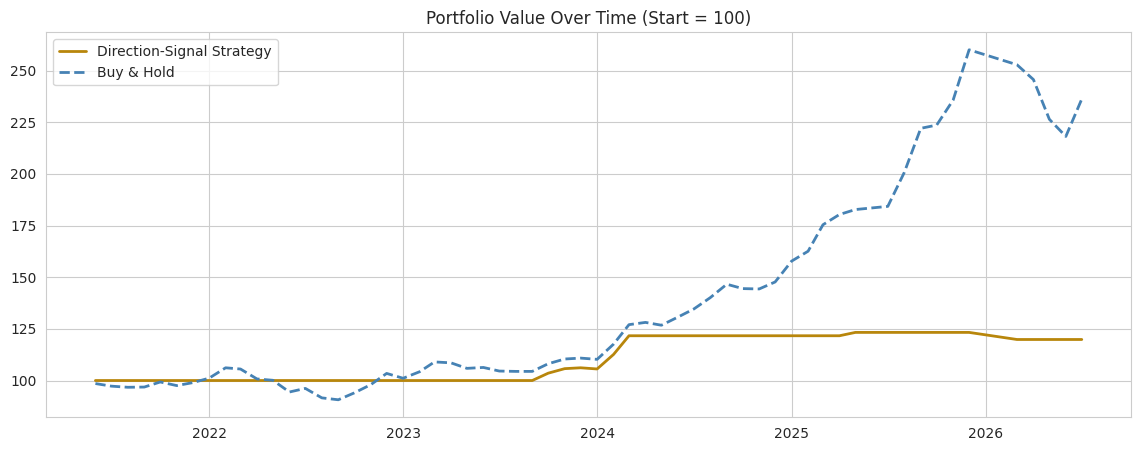

In [22]:
realized_return = test["Target_Price"] / test["Gold"] - 1
strategy_return = realized_return * clf_pred
buyhold_return = realized_return

strategy_equity = (1 + strategy_return).cumprod() * 100
buyhold_equity = (1 + buyhold_return).cumprod() * 100

plt.figure(figsize=(14, 5))
plt.plot(test.index, strategy_equity, label="Direction-Signal Strategy", color="darkgoldenrod", linewidth=2)
plt.plot(test.index, buyhold_equity, label="Buy & Hold", color="steelblue", linewidth=2, linestyle="--")
plt.title("Portfolio Value Over Time (Start = 100)")
plt.legend()
plt.show()


In [23]:
def sharpe_ratio(returns):
    if returns.std() == 0:
        return 0.0
    return (returns.mean() / returns.std()) * np.sqrt(12)

def max_drawdown(equity):
    running_max = equity.cummax()
    return ((equity - running_max) / running_max).min() * 100

backtest_summary = pd.DataFrame({
    "Strategy": ["Direction-Signal Strategy", "Buy & Hold"],
    "Total Return (%)": [
        (strategy_equity.iloc[-1] / 100 - 1) * 100,
        (buyhold_equity.iloc[-1] / 100 - 1) * 100,
    ],
    "Sharpe Ratio": [sharpe_ratio(strategy_return), sharpe_ratio(buyhold_return)],
    "Max Drawdown (%)": [max_drawdown(strategy_equity), max_drawdown(buyhold_equity)],
})
win_rate = (clf_pred == test["Target_Direction"]).mean() * 100
print(f"Direction Win Rate: {win_rate:.1f}%")
backtest_summary


Direction Win Rate: 45.8%


,Strategy,Total Return (%),Sharpe Ratio,Max Drawdown (%)
0,Direction-Signal Strategy,19.850232,0.736112,-2.780066
1,Buy & Hold,136.198542,1.355332,-16.124382


**How to read this:**
- **Sharpe Ratio** measures return per unit of risk (annualized here since data is monthly) —
  a strategy beating Buy & Hold on Sharpe is delivering smoother, more risk-adjusted gains,
  not just bigger swings.
- **Max Drawdown** is the worst peak-to-trough decline the strategy would have experienced.
- **Direction Win Rate** is how often the classifier's Up/Down call matched what actually
  happened next month.

**Honest caveat:** this backtest ignores transaction costs, slippage, and taxes, and assumes
the strategy can move fully in or out of gold every month with zero delay — none of which
holds in real trading. If Buy & Hold wins here, that's a genuinely useful (and common)
finding — it means the classifier isn't yet adding value over a naive baseline, which is
exactly the kind of honest result a credible project should report rather than hide.


## Section 9: Limitations & Future Work

**Limitations:**
- Financial markets are influenced by unpredictable events (geopolitics, central bank
  announcements, wars) that no historical-data model can anticipate.
- This notebook uses free, public monthly data sources; a production trading system would
  use a paid, higher-frequency provider (Bloomberg, Refinitiv) for daily/intraday signals.
- Backtesting on a single historical period risks overfitting to that period's regime.

**Future Work:**
- Add PKR/USD exchange rate for a Pakistan-specific gold analysis
- Add news/sentiment data (headlines, central bank statements)
- Add an LSTM/Prophet deep-learning model for comparison
- Build a proper backtest with a simulated trading strategy (position sizing, Sharpe ratio,
  max drawdown) rather than just point-forecast accuracy
- Move to a daily-frequency paid data provider for higher-resolution signals

## Section 10: Conclusion

This project demonstrates an end-to-end forecasting pipeline that goes beyond simple price
prediction by grounding gold price movement in **macroeconomic reasoning** (USD, oil, equity
market stress), comparing multiple modeling paradigms (classical statistical vs ML), and
being explicit about where the model's real-world limitations lie — which matters more for
a credible financial ML project than squeezing out a marginally lower RMSE.

This project also goes a step further than pure forecasting: it converts findings into a
**Pakistan-specific PKR view** (Section 1B) and stress-tests the model's practical value with
a **backtest against Buy & Hold** (Section 8B) — reporting the honest result rather than only
the flattering one.

Everything above — data loading, feature engineering, modeling, and evaluation — runs from
this single notebook, with no external `.py` files required.
